# VIS detection comparison: classical, v8 CenterNet, v8 StemCenterNet

Three detection views overlaid on the same VIS tile:

1. **Classical VIS** -- native-resolution peak finder on the Euclid VIS image.
   Fast, robust, and the bootstrap source list everything else is compared to.
2. **V8 CenterNet (round 2)** -- bottleneck-path neural detector trained on the
   v8 fine-scale foundation features. Sees all 10 bands through the frozen v8
   encoder and predicts source positions directly in the VIS frame.
3. **V8 StemCenterNet (round 2)** -- native-resolution stem-path detector on the
   same v8 foundation. Operates on the BandStem features before bottleneck
   downsampling, preserving more local spatial detail. Trained via
   `models/detection/self_train_stem.py` against `jaisp_v8_fine`.

Both neural detectors share the same v8 foundation; the only difference is the
detection head and where in the encoder it taps in (bottleneck vs. stem).

The classical detector is **not treated as ground truth**. The point is to see
all three on the same tile, where the neural detectors agree, where they
disagree, and where they go beyond classical -- particularly for faint sources
that are only visible after the foundation model fuses the multi-band info.

Foundation: `models/checkpoints/jaisp_v8_fine/checkpoint_best.pt`


In [8]:
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    raise FileNotFoundError('Could not find repo root containing models/ and data/.')


REPO = find_repo_root()
MODELS = REPO / 'models'
for path in [MODELS, MODELS / 'detection', MODELS / 'astrometry2']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from load_foundation import load_foundation
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from detection.stem_centernet_detector import StemCenterNetDetector
from detection.dataset import _pseudo_labels_vis

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Repo root: {REPO}')
print(f'Device: {DEVICE}')


def safe_rms_from_var(var: np.ndarray) -> np.ndarray:
    var = np.asarray(var, dtype=np.float32)
    good = np.isfinite(var) & (var > 0) & (var < 1e20)
    fallback = float(np.sqrt(np.median(var[good]))) if good.any() else 1.0
    out = np.full(var.shape, fallback, dtype=np.float32)
    out[good] = np.sqrt(var[good])
    return out


def to_tensor_1chw(arr: np.ndarray, device: torch.device) -> torch.Tensor:
    arr = np.asarray(arr, dtype=np.float32)
    return torch.from_numpy(arr[None, None]).to(device)


def pick_random_tile_name(rubin_dir: Path, euclid_dir: Path, seed: Optional[int] = None) -> str:
    rubin_stems = sorted(p.stem for p in rubin_dir.glob('tile_x*_y*.npz'))
    shared = [stem for stem in rubin_stems if (euclid_dir / f'{stem}_euclid.npz').exists()]
    if not shared:
        raise RuntimeError('No shared Rubin/Euclid tiles found in the selected directories.')
    rng = np.random.default_rng(seed)
    return str(rng.choice(shared))


def vis_centroids_to_xy(centroids_norm: np.ndarray, hw: tuple[int, int]) -> np.ndarray:
    h, w = hw
    if len(centroids_norm) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    return np.stack([
        centroids_norm[:, 0] * max(w - 1, 1),
        centroids_norm[:, 1] * max(h - 1, 1),
    ], axis=1).astype(np.float32)


def stretch_image(img: np.ndarray, lo: float = 1.0, hi: float = 99.5) -> np.ndarray:
    img = np.asarray(img, dtype=np.float32)
    finite = np.isfinite(img)
    if not finite.any():
        return np.zeros_like(img, dtype=np.float32)
    vals = img[finite]
    vmin, vmax = np.percentile(vals, [lo, hi])
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return np.clip((np.nan_to_num(img, nan=vmin) - vmin) / (vmax - vmin), 0.0, 1.0)


def load_centernet_detector(foundation_ckpt: Path, detector_ckpt: Path, device: torch.device) -> CenterNetDetector:
    foundation = load_foundation(str(foundation_ckpt), device=device, freeze=True)
    encoder = JAISPEncoderWrapper(foundation, freeze=True).to(device)
    detector = CenterNetDetector.load(str(detector_ckpt), encoder=encoder, device=device)
    return detector.eval()


def load_stem_centernet_detector(foundation_ckpt: Path, detector_ckpt: Path, device: torch.device) -> StemCenterNetDetector:
    foundation = load_foundation(str(foundation_ckpt), device=device, freeze=True)
    detector = StemCenterNetDetector.load(str(detector_ckpt), foundation, device=device)
    return detector.eval()


def load_tile_pair(stem: str, rubin_dir: Path, euclid_dir: Path, device: torch.device) -> dict:
    rubin_path = rubin_dir / f'{stem}.npz'
    euclid_path = euclid_dir / f'{stem}_euclid.npz'
    if not rubin_path.exists():
        raise FileNotFoundError(rubin_path)
    if not euclid_path.exists():
        raise FileNotFoundError(euclid_path)

    r = np.load(rubin_path, allow_pickle=True)
    e = np.load(euclid_path, allow_pickle=True)

    rubin_img = np.nan_to_num(np.asarray(r['img'], dtype=np.float32), nan=0.0)
    rubin_var = np.asarray(r['var'], dtype=np.float32)
    rubin_rms = np.stack([safe_rms_from_var(v) for v in rubin_var], axis=0)

    vis_img = np.nan_to_num(np.asarray(e['img_VIS'], dtype=np.float32), nan=0.0)
    vis_hw = tuple(vis_img.shape)

    images = {
        'rubin_u': to_tensor_1chw(rubin_img[0], device),
        'rubin_g': to_tensor_1chw(rubin_img[1], device),
        'rubin_r': to_tensor_1chw(rubin_img[2], device),
        'rubin_i': to_tensor_1chw(rubin_img[3], device),
        'rubin_z': to_tensor_1chw(rubin_img[4], device),
        'rubin_y': to_tensor_1chw(rubin_img[5], device),
        'euclid_VIS': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_VIS'], dtype=np.float32), nan=0.0), device),
        'euclid_Y': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_Y'], dtype=np.float32), nan=0.0), device),
        'euclid_J': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_J'], dtype=np.float32), nan=0.0), device),
        'euclid_H': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_H'], dtype=np.float32), nan=0.0), device),
    }
    rms = {
        'rubin_u': to_tensor_1chw(rubin_rms[0], device),
        'rubin_g': to_tensor_1chw(rubin_rms[1], device),
        'rubin_r': to_tensor_1chw(rubin_rms[2], device),
        'rubin_i': to_tensor_1chw(rubin_rms[3], device),
        'rubin_z': to_tensor_1chw(rubin_rms[4], device),
        'rubin_y': to_tensor_1chw(rubin_rms[5], device),
        'euclid_VIS': to_tensor_1chw(safe_rms_from_var(e['var_VIS']), device),
        'euclid_Y': to_tensor_1chw(safe_rms_from_var(e['var_Y']), device),
        'euclid_J': to_tensor_1chw(safe_rms_from_var(e['var_J']), device),
        'euclid_H': to_tensor_1chw(safe_rms_from_var(e['var_H']), device),
    }

    return {
        'stem': stem,
        'rubin_path': rubin_path,
        'euclid_path': euclid_path,
        'vis_img': vis_img,
        'vis_hw': vis_hw,
        'images': images,
        'rms': rms,
    }


def run_detector(detector, images: dict, rms: dict, tile_hw: tuple[int, int], conf_threshold: float) -> tuple[np.ndarray, np.ndarray]:
    with torch.no_grad():
        pred = detector.predict(images, rms, conf_threshold=conf_threshold, tile_hw=tile_hw)
    xy = pred['positions_px'].detach().cpu().numpy().astype(np.float32)
    scores = pred['scores'].detach().cpu().numpy().astype(np.float32)
    return xy, scores

Repo root: /home/shemmati/Work/Projects/JAISP
Device: cuda


In [9]:
RUBIN_DIR = REPO / 'data' / 'rubin_tiles_patch25_box16'
EUCLID_DIR = REPO / 'data' / 'euclid_tiles_patch25_box16'
# Both neural detectors live on the v8 fine-scale foundation (current production).
FOUNDATION_V8_CKPT = MODELS / 'checkpoints' / 'jaisp_v8_fine' / 'checkpoint_best.pt'
CENTERNET_ROUND2_CKPT = REPO / 'checkpoints' / 'centernet_v8_fine' / 'centernet_best.pt'
STEM_CENTERNET_ROUND2_CKPT = REPO / 'checkpoints' / 'stem_centernet_v8_fine' / 'stem_centernet_best.pt'

RANDOM_TILE_SEED = None
CLASSICAL_VIS_NSIG = 3.0
CENTERNET_CONF_THRESHOLD = 0.30
STEM_CENTERNET_CONF_THRESHOLD = 0.30

assert RUBIN_DIR.exists(), RUBIN_DIR
assert EUCLID_DIR.exists(), EUCLID_DIR
assert FOUNDATION_V8_CKPT.exists(), FOUNDATION_V8_CKPT
assert CENTERNET_ROUND2_CKPT.exists(), CENTERNET_ROUND2_CKPT
assert STEM_CENTERNET_ROUND2_CKPT.exists(), STEM_CENTERNET_ROUND2_CKPT

TILE_NAME = pick_random_tile_name(RUBIN_DIR, EUCLID_DIR, seed=RANDOM_TILE_SEED)
print(f'V8 foundation : {FOUNDATION_V8_CKPT}')
print(f'CenterNet r2   : {CENTERNET_ROUND2_CKPT}')
print(f'StemCenterNet  : {STEM_CENTERNET_ROUND2_CKPT}')
print(f'Random tile    : {TILE_NAME}')


V8 foundation : /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v8_fine/checkpoint_best.pt
CenterNet r2   : /home/shemmati/Work/Projects/JAISP/checkpoints/centernet_v8_fine/centernet_best.pt
StemCenterNet  : /home/shemmati/Work/Projects/JAISP/checkpoints/stem_centernet_v8_fine/stem_centernet_best.pt
Random tile    : tile_x00768_y00512_tract5063_patch_25


In [10]:
tile = load_tile_pair(TILE_NAME, RUBIN_DIR, EUCLID_DIR, DEVICE)
centernet = load_centernet_detector(FOUNDATION_V8_CKPT, CENTERNET_ROUND2_CKPT, DEVICE)
stem_centernet = load_stem_centernet_detector(FOUNDATION_V8_CKPT, STEM_CENTERNET_ROUND2_CKPT, DEVICE)

vis_centroids_norm, _, _, _ = _pseudo_labels_vis(tile['vis_img'], nsig=CLASSICAL_VIS_NSIG, max_sources=1000)
vis_classical_xy = vis_centroids_to_xy(vis_centroids_norm, tile['vis_hw'])

centernet_xy, centernet_scores = run_detector(
    centernet,
    tile['images'],
    tile['rms'],
    tile['vis_hw'],
    CENTERNET_CONF_THRESHOLD,
)
stem_xy, stem_scores = run_detector(
    stem_centernet,
    tile['images'],
    tile['rms'],
    tile['vis_hw'],
    STEM_CENTERNET_CONF_THRESHOLD,
)

print(tile['euclid_path'].name)
print(f'VIS classical detections: {len(vis_classical_xy)}')
print(f'V8 + CenterNet round-2 detections: {len(centernet_xy)}')
print(f'V8 + StemCenterNet round-2 detections: {len(stem_xy)}')
print(f'CenterNet median score: {np.median(centernet_scores):.3f}' if len(centernet_scores) else 'CenterNet median score: n/a')
print(f'StemCenterNet median score: {np.median(stem_scores):.3f}' if len(stem_scores) else 'StemCenterNet median score: n/a')


JAISPFoundationV8: 9.1M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v8 foundation (fused_scale=0.4) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v8_fine/checkpoint_best.pt
JAISPFoundationV8: 9.1M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v8 foundation (fused_scale=0.4) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v8_fine/checkpoint_best.pt
tile_x00768_y00512_tract5063_patch_25_euclid.npz
VIS classical detections: 221
V8 + CenterNet round-2 detections: 231
V8 + StemCenterNet round-2 detections: 282
CenterNet median score: 0.476
StemCenterNet median score: 0.544


In [11]:
# ── Sanity check before injection: do the neural detectors find real VIS sources? ──
# Classical peak-finding over-counts diffraction spikes around bright stars (one star → many
# pseudo-detections), so simple "recall vs classical" is unreliable. We build two cleaner
# references and report MUTUAL nearest-neighbour agreement (each side gets at most one match
# per source), so spike clusters cannot inflate either recall or precision.
#
#   - dedup_classical : classical peaks deduplicated with greedy NN at 6 px (~0.6"), sorted
#                       by local VIS intensity. Kills spike rings around bright stars while
#                       preserving genuine close pairs.
#   - isolated_bright : dedup_classical further restricted to peaks that have NO other peak
#                       within 15 px AND sit in the top intensity tercile. The cleanest
#                       reference -- effectively isolated bright sources only.
#
# We also report stem ↔ CenterNet mutual agreement directly, since CenterNet is a more
# reliable reference than classical for "real source" judgement.

from scipy.spatial import cKDTree as _cKDTree


def _local_vis_intensity(xy: np.ndarray, vis_img: np.ndarray, half: int = 2) -> np.ndarray:
    """Mean VIS pixel value in a (2*half+1)^2 patch around each (x, y)."""
    H, W = vis_img.shape
    out = np.zeros(len(xy), dtype=np.float32)
    for i, (x, y) in enumerate(xy):
        ix = int(round(x)); iy = int(round(y))
        x0, x1 = max(0, ix - half), min(W, ix + half + 1)
        y0, y1 = max(0, iy - half), min(H, iy + half + 1)
        patch = vis_img[y0:y1, x0:x1]
        if patch.size:
            out[i] = float(np.nanmean(patch))
    return out


def _greedy_nn_dedup(xy: np.ndarray, intensity: np.ndarray, radius_px: float) -> np.ndarray:
    """Greedy NN dedup. Iterate brightest first; skip any point within `radius_px` of a kept point."""
    if len(xy) == 0:
        return np.zeros(0, dtype=int)
    order = np.argsort(-intensity)  # brightest first
    kept_xy: list[np.ndarray] = []
    kept_idx: list[int] = []
    for i in order:
        if not kept_idx:
            kept_xy.append(xy[i]); kept_idx.append(int(i)); continue
        d = np.sqrt(((np.asarray(kept_xy) - xy[i]) ** 2).sum(axis=1))
        if d.min() >= radius_px:
            kept_xy.append(xy[i]); kept_idx.append(int(i))
    return np.asarray(kept_idx, dtype=int)


def _mutual_nn_match(pred_xy: np.ndarray, ref_xy: np.ndarray, radius_px: float) -> dict:
    """Mutual nearest-neighbour. A ref/pred pair counts only when each is the other's nearest
    AND their distance ≤ radius_px. Each source matches at most once.
    Returns recall (refs matched / N_refs) and precision (preds matched / N_preds).
    """
    if len(pred_xy) == 0 or len(ref_xy) == 0:
        return {"recall": 0.0, "precision": 0.0, "n_pred": int(len(pred_xy)), "n_ref": int(len(ref_xy)), "n_match": 0}
    tree_pred = _cKDTree(pred_xy)
    tree_ref  = _cKDTree(ref_xy)
    d_rp, idx_rp = tree_pred.query(ref_xy)   # for each ref, nearest pred
    d_pr, idx_pr = tree_ref.query(pred_xy)   # for each pred, nearest ref
    matched = 0
    for i_ref, j_pred in enumerate(idx_rp):
        if d_rp[i_ref] <= radius_px and idx_pr[j_pred] == i_ref:
            matched += 1
    return {"recall":    matched / max(len(ref_xy),  1),
            "precision": matched / max(len(pred_xy), 1),
            "n_pred":    int(len(pred_xy)),
            "n_ref":     int(len(ref_xy)),
            "n_match":   int(matched)}


# Build the two cleaner classical references on the uninjected tile.
DEDUP_RADIUS_PX  = 6.0    # spike-kill radius
ISOLATE_RADIUS_PX = 15.0  # "no other source nearby"
MATCH_RADIUS_PX  = 5.0    # ~0.5" tolerance for "same source"

vis_img = tile["vis_img"]
classical_intensity = _local_vis_intensity(vis_classical_xy, vis_img)
keep_dedup = _greedy_nn_dedup(vis_classical_xy, classical_intensity, DEDUP_RADIUS_PX)
dedup_xy = vis_classical_xy[keep_dedup]
dedup_int = classical_intensity[keep_dedup]

# isolated_bright = dedup peaks with no neighbour within ISOLATE_RADIUS_PX, AND in top intensity tercile.
if len(dedup_xy) >= 6:
    tree_d = _cKDTree(dedup_xy)
    nn2_d, _ = tree_d.query(dedup_xy, k=2)   # nearest other peak
    isolated_mask = nn2_d[:, 1] >= ISOLATE_RADIUS_PX
    int_thresh = float(np.percentile(dedup_int[isolated_mask], 66.7)) if isolated_mask.any() else 0.0
    bright_mask = dedup_int >= int_thresh
    iso_idx = np.where(isolated_mask & bright_mask)[0]
    isolated_xy = dedup_xy[iso_idx]
else:
    isolated_xy = np.zeros((0, 2), dtype=np.float32)

print(f"Reference building (cleaned classical):")
print(f"  classical raw           N = {len(vis_classical_xy):>5}")
print(f"  classical dedup ({DEDUP_RADIUS_PX:.0f}px)  N = {len(dedup_xy):>5}   "
      f"(removed {len(vis_classical_xy)-len(dedup_xy)} spike-cluster duplicates)")
print(f"  isolated bright         N = {len(isolated_xy):>5}   "
      f"(no neighbour within {ISOLATE_RADIUS_PX:.0f}px, top-tercile intensity)")
print()


def _row(label: str, pred_xy: np.ndarray, ref_xy: np.ndarray, ref_label: str) -> None:
    s = _mutual_nn_match(pred_xy, ref_xy, MATCH_RADIUS_PX)
    print(f"  {label:<22s} vs {ref_label:<20s}  N={s['n_pred']:>4}  "
          f"recall={s['recall']*100:5.1f}%   precision={s['precision']*100:5.1f}%   "
          f"matched={s['n_match']}")


print(f"Mutual nearest-neighbour agreement (radius = {MATCH_RADIUS_PX:.1f}px ≈ "
      f"{MATCH_RADIUS_PX*0.1:.2f}\"):")
_row("V8 CenterNet",     centernet_xy, dedup_xy,    "dedup classical")
_row("V8 StemCenterNet", stem_xy,      dedup_xy,    "dedup classical")
print()
_row("V8 CenterNet",     centernet_xy, isolated_xy, "isolated bright")
_row("V8 StemCenterNet", stem_xy,      isolated_xy, "isolated bright")
print()
_row("V8 StemCenterNet", stem_xy,      centernet_xy, "V8 CenterNet")
_row("V8 CenterNet",     centernet_xy, stem_xy,      "V8 StemCenterNet")
print()


def _heatmap_stats(detector, label: str) -> None:
    with torch.no_grad():
        out = detector(tile["images"], tile["rms"])
    hm = out["heatmap"][0, 0].detach().cpu().numpy()
    print(f"  {label:>20s}  hm shape={hm.shape}  max={hm.max():.3f}  "
          f"med={np.median(hm):.4f}  frac>0.30 = {(hm > 0.30).mean()*100:.3f}%   "
          f"frac>0.50 = {(hm > 0.50).mean()*100:.4f}%")


print("Heatmap statistics (input = uninjected tile, no NMS, no threshold):")
_heatmap_stats(centernet,      "V8 CenterNet")
_heatmap_stats(stem_centernet, "V8 StemCenterNet")

print()
print("Reading:")
print("  - Both detectors' recall on isolated-bright should be very high (>90%); these")
print("    are unambiguously real, isolated sources. Lower recall here = real model issue.")
print("  - Stem precision against dedup classical << CenterNet precision → stem is firing")
print("    on more clusters classical also flags as duplicates (e.g. extended objects).")
print("  - If stem ↔ CenterNet mutual agreement is high but stem fails on NIR-only injection,")
print("    that confirms training-distribution bias: stem learned VIS-anchored detection only.")


Reference building (cleaned classical):
  classical raw           N =   221
  classical dedup (6px)  N =   220   (removed 1 spike-cluster duplicates)
  isolated bright         N =    63   (no neighbour within 15px, top-tercile intensity)

Mutual nearest-neighbour agreement (radius = 5.0px ≈ 0.50"):
  V8 CenterNet           vs dedup classical       N= 231  recall= 77.7%   precision= 74.0%   matched=171
  V8 StemCenterNet       vs dedup classical       N= 282  recall= 96.8%   precision= 75.5%   matched=213

  V8 CenterNet           vs isolated bright       N= 231  recall= 90.5%   precision= 24.7%   matched=57
  V8 StemCenterNet       vs isolated bright       N= 282  recall= 95.2%   precision= 21.3%   matched=60

  V8 StemCenterNet       vs V8 CenterNet          N= 282  recall= 93.9%   precision= 77.0%   matched=217
  V8 CenterNet           vs V8 StemCenterNet      N= 231  recall= 77.0%   precision= 93.9%   matched=217

Heatmap statistics (input = uninjected tile, no NMS, no threshold):
 

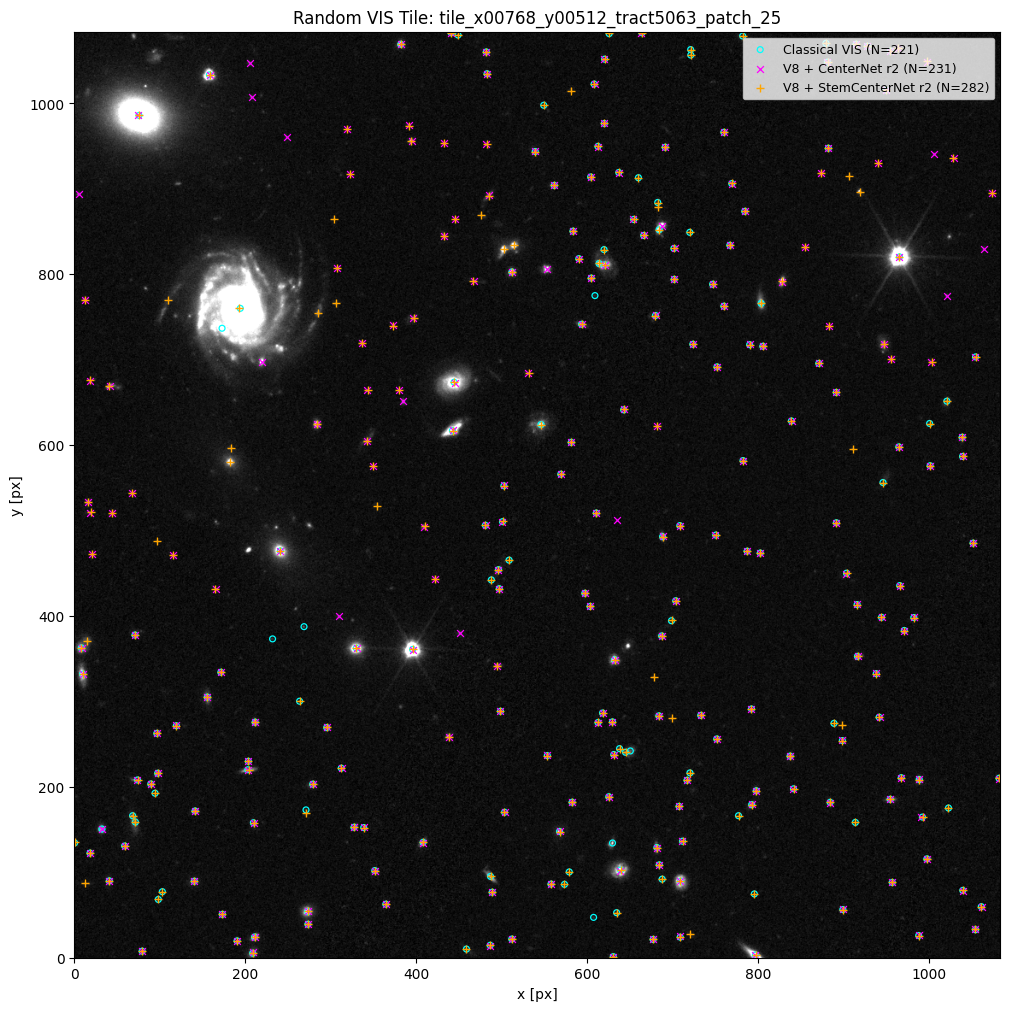

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)

ax.imshow(stretch_image(tile['vis_img']), cmap='gray', origin='lower')

if len(vis_classical_xy):
    ax.scatter(
        vis_classical_xy[:, 0],
        vis_classical_xy[:, 1],
        s=18,
        facecolors='none',
        edgecolors='cyan',
        linewidths=0.9,
        marker='o',
        label=f'Classical VIS (N={len(vis_classical_xy)})',
    )

if len(centernet_xy):
    ax.scatter(
        centernet_xy[:, 0],
        centernet_xy[:, 1],
        s=24,
        c='magenta',
        marker='x',
        linewidths=0.9,
        label=f'V8 + CenterNet r2 (N={len(centernet_xy)})',
    )

if len(stem_xy):
    ax.scatter(
        stem_xy[:, 0],
        stem_xy[:, 1],
        s=28,
        c='orange',
        marker='+',
        linewidths=1.0,
        label=f'V8 + StemCenterNet r2 (N={len(stem_xy)})',
    )

ax.set_title(f'Random VIS Tile: {tile["stem"]}')
ax.set_xlim(0, tile['vis_hw'][1])
ax.set_ylim(0, tile['vis_hw'][0])
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(loc='upper right', fontsize=9)
plt.show()


NIR-only injection recovery on the current random tile
  tile: tile_x00768_y00512_tract5063_patch_25
  injected blob: sigma_x=3.2px, sigma_y=2.2px, theta=25.0 deg
  injected bands: {'euclid_Y': 6.0, 'euclid_J': 8.0, 'euclid_H': 10.0}
  trials: 6
  V8 + CenterNet recovered: 4 / 6
  V8 + StemCenterNet recovered: 0 / 6
  trial 1: (x=981.0, y=665.0) | CenterNet=True (d=0.19) | Stem=False (d=39.22)
  trial 2: (x=723.0, y=934.0) | CenterNet=True (d=0.20) | Stem=False (d=34.76)
  trial 3: (x=102.0, y=344.0) | CenterNet=True (d=0.42) | Stem=False (d=45.89)
  trial 4: (x=949.0, y=53.0) | CenterNet=True (d=0.59) | Stem=False (d=36.15)
  trial 5: (x=541.0, y=859.0) | CenterNet=False (d=43.39) | Stem=False (d=36.29)
  trial 6: (x=177.0, y=835.0) | CenterNet=False (d=133.03) | Stem=False (d=76.65)


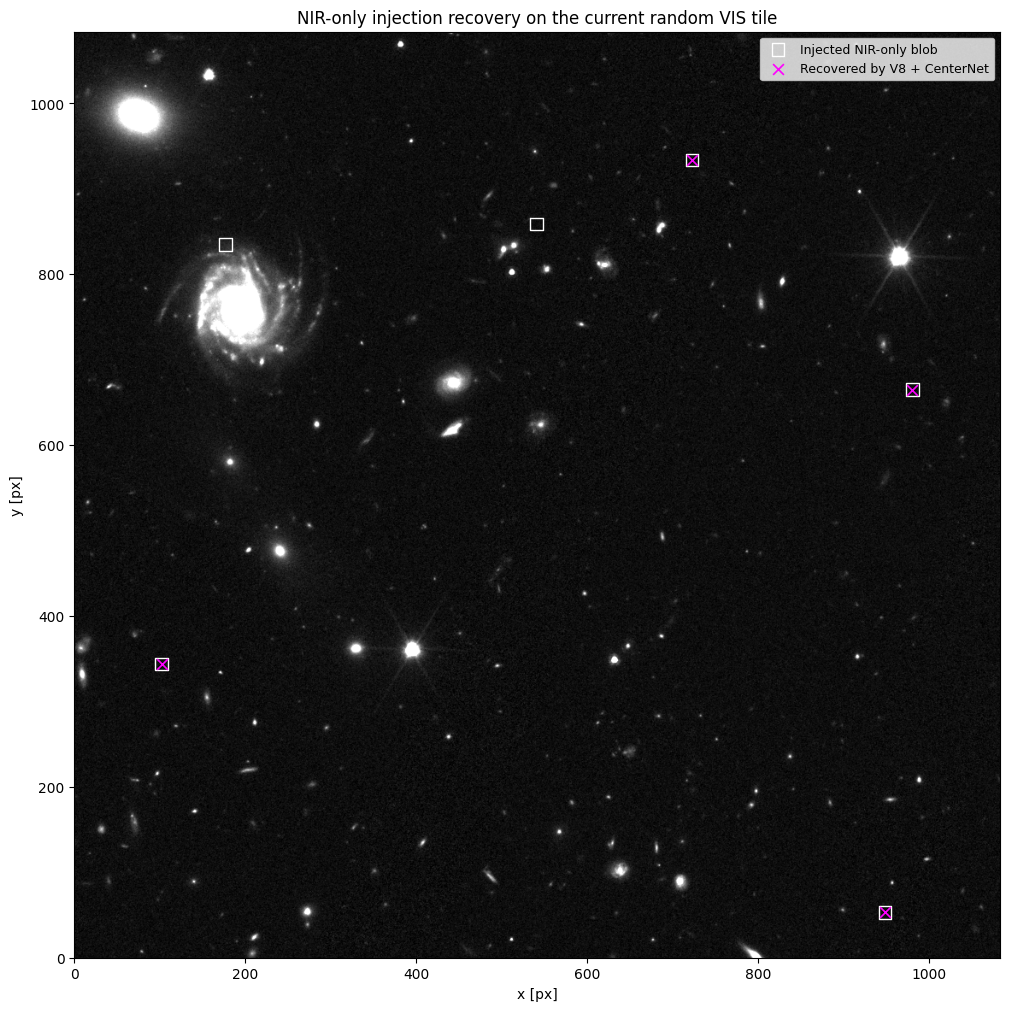

In [13]:
from scipy.spatial import cKDTree

INJECT_RANDOM_SEED = 7
INJECT_N_TRIALS = 6
INJECT_BORDER_PX = 48
INJECT_MIN_DIST_EXISTING_PX = 24.0
INJECT_MATCH_RADIUS_PX = 8.0
INJECT_SIGMA_X_PX = 3.2
INJECT_SIGMA_Y_PX = 2.2
INJECT_THETA_DEG = 25.0
INJECT_SNR_BY_BAND = {
    'euclid_Y': 6.0,
    'euclid_J': 8.0,
    'euclid_H': 10.0,
}


def clone_band_dict(d: dict) -> dict:
    return {k: v.clone() for k, v in d.items()}


def local_rms_value(rms_tensor: torch.Tensor, x: float, y: float, half_size: int = 3) -> float:
    arr = rms_tensor[0, 0].detach().cpu().numpy()
    H, W = arr.shape
    xi = int(round(x))
    yi = int(round(y))
    x0 = max(0, xi - half_size)
    x1 = min(W, xi + half_size + 1)
    y0 = max(0, yi - half_size)
    y1 = min(H, yi + half_size + 1)
    patch = arr[y0:y1, x0:x1]
    finite = np.isfinite(patch) & (patch > 0)
    if finite.any():
        return float(np.median(patch[finite]))
    return 1.0


def inject_gaussian_blob(images: dict, rms: dict, x: float, y: float, sigma_x_px: float, sigma_y_px: float, theta_deg: float, snr_by_band: dict) -> dict:
    out = clone_band_dict(images)
    bands = [b for b, snr in snr_by_band.items() if snr > 0 and b in out]
    if not bands:
        return out

    sample = out[bands[0]][0, 0]
    H, W = sample.shape
    radius = int(max(6, np.ceil(4 * max(sigma_x_px, sigma_y_px))))
    x0 = max(0, int(np.floor(x)) - radius)
    x1 = min(W, int(np.floor(x)) + radius + 1)
    y0 = max(0, int(np.floor(y)) - radius)
    y1 = min(H, int(np.floor(y)) + radius + 1)
    yy, xx = np.mgrid[y0:y1, x0:x1]
    th = np.deg2rad(theta_deg)
    dx = xx - x
    dy = yy - y
    xp = np.cos(th) * dx + np.sin(th) * dy
    yp = -np.sin(th) * dx + np.cos(th) * dy
    stamp = np.exp(-0.5 * ((xp / sigma_x_px) ** 2 + (yp / sigma_y_px) ** 2)).astype(np.float32)
    stamp /= max(float(stamp.max()), 1e-6)

    for band in bands:
        amp = snr_by_band[band] * local_rms_value(rms[band], x, y)
        band_stamp = torch.from_numpy((amp * stamp)[None, None]).to(out[band].device, dtype=out[band].dtype)
        out[band][:, :, y0:y1, x0:x1] = out[band][:, :, y0:y1, x0:x1] + band_stamp
    return out


def pick_injection_positions(existing_xy: np.ndarray, hw: tuple[int, int], n_trials: int, seed: int, border: int, min_dist_px: float) -> np.ndarray:
    H, W = hw
    rng = np.random.default_rng(seed)
    pts = []
    tree = cKDTree(existing_xy) if len(existing_xy) else None
    attempts = 0
    max_attempts = max(200, n_trials * 200)
    while len(pts) < n_trials and attempts < max_attempts:
        attempts += 1
        x = float(rng.integers(border, max(border + 1, W - border)))
        y = float(rng.integers(border, max(border + 1, H - border)))
        if tree is not None:
            d, _ = tree.query([[x, y]], distance_upper_bound=min_dist_px)
            if np.isfinite(d[0]):
                continue
        if pts:
            d_self = np.sqrt(np.sum((np.asarray(pts) - np.array([[x, y]])) ** 2, axis=1))
            if np.any(d_self < min_dist_px):
                continue
        pts.append([x, y])
    if len(pts) < n_trials:
        print(f'Warning: only found {len(pts)} valid injection positions out of requested {n_trials}.')
    return np.asarray(pts, dtype=np.float32)


def recovered_near(pred_xy: np.ndarray, x: float, y: float, radius_px: float) -> tuple[bool, float]:
    if len(pred_xy) == 0:
        return False, float('inf')
    d = np.sqrt(np.sum((pred_xy - np.array([[x, y]], dtype=np.float32)) ** 2, axis=1))
    return bool(np.any(d <= radius_px)), float(d.min())


existing_xy = np.concatenate([arr for arr in [vis_classical_xy, centernet_xy, stem_xy] if len(arr)], axis=0) if any(len(arr) for arr in [vis_classical_xy, centernet_xy, stem_xy]) else np.zeros((0, 2), dtype=np.float32)
inject_xy = pick_injection_positions(
    existing_xy=existing_xy,
    hw=tile['vis_hw'],
    n_trials=INJECT_N_TRIALS,
    seed=INJECT_RANDOM_SEED,
    border=INJECT_BORDER_PX,
    min_dist_px=INJECT_MIN_DIST_EXISTING_PX,
)

results = []
for x, y in inject_xy:
    injected_images = inject_gaussian_blob(
        tile['images'],
        tile['rms'],
        x=float(x),
        y=float(y),
        sigma_x_px=INJECT_SIGMA_X_PX,
        sigma_y_px=INJECT_SIGMA_Y_PX,
        theta_deg=INJECT_THETA_DEG,
        snr_by_band=INJECT_SNR_BY_BAND,
    )
    c_xy, _ = run_detector(centernet, injected_images, tile['rms'], tile['vis_hw'], CENTERNET_CONF_THRESHOLD)
    s_xy, _ = run_detector(stem_centernet, injected_images, tile['rms'], tile['vis_hw'], STEM_CENTERNET_CONF_THRESHOLD)
    c_hit, c_dmin = recovered_near(c_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
    s_hit, s_dmin = recovered_near(s_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
    results.append({
        'x': float(x),
        'y': float(y),
        'centernet_hit': c_hit,
        'centernet_dmin': c_dmin,
        'stem_hit': s_hit,
        'stem_dmin': s_dmin,
    })

centernet_hits = sum(r['centernet_hit'] for r in results)
stem_hits = sum(r['stem_hit'] for r in results)

print('NIR-only injection recovery on the current random tile')
print(f'  tile: {tile["stem"]}')
print(f'  injected blob: sigma_x={INJECT_SIGMA_X_PX}px, sigma_y={INJECT_SIGMA_Y_PX}px, theta={INJECT_THETA_DEG} deg')
print(f'  injected bands: {INJECT_SNR_BY_BAND}')
print(f'  trials: {len(results)}')
print(f'  V8 + CenterNet recovered: {centernet_hits} / {len(results)}')
print(f'  V8 + StemCenterNet recovered: {stem_hits} / {len(results)}')
for i, r in enumerate(results, 1):
    print(
        f'  trial {i}: (x={r["x"]:.1f}, y={r["y"]:.1f}) | '
        f'CenterNet={r["centernet_hit"]} (d={r["centernet_dmin"]:.2f}) | '
        f'Stem={r["stem_hit"]} (d={r["stem_dmin"]:.2f})'
    )

fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)
ax.imshow(stretch_image(tile['vis_img']), cmap='gray', origin='lower')
if len(inject_xy):
    ax.scatter(inject_xy[:, 0], inject_xy[:, 1], s=80, facecolors='none', edgecolors='white', marker='s', linewidths=1.0, label='Injected NIR-only blob')
centernet_rec = np.array([[r['x'], r['y']] for r in results if r['centernet_hit']], dtype=np.float32)
stem_rec = np.array([[r['x'], r['y']] for r in results if r['stem_hit']], dtype=np.float32)
if len(centernet_rec):
    ax.scatter(centernet_rec[:, 0], centernet_rec[:, 1], s=60, c='magenta', marker='x', linewidths=1.2, label='Recovered by V8 + CenterNet')
if len(stem_rec):
    ax.scatter(stem_rec[:, 0], stem_rec[:, 1], s=90, c='orange', marker='+', linewidths=1.4, label='Recovered by V8 + StemCenterNet')
ax.set_title('NIR-only injection recovery on the current random VIS tile')
ax.set_xlim(0, tile['vis_hw'][1])
ax.set_ylim(0, tile['vis_hw'][0])
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(loc='upper right', fontsize=9)
plt.show()


Sweep tiles:
  - tile_x00000_y00256_tract5063_patch_25
  - tile_x00256_y00768_tract5063_patch_25
  - tile_x00768_y00256_tract5063_patch_25
  - tile_x00512_y00768_tract5063_patch_25
Recovery fractions are over tiles x injected positions for each grid point.


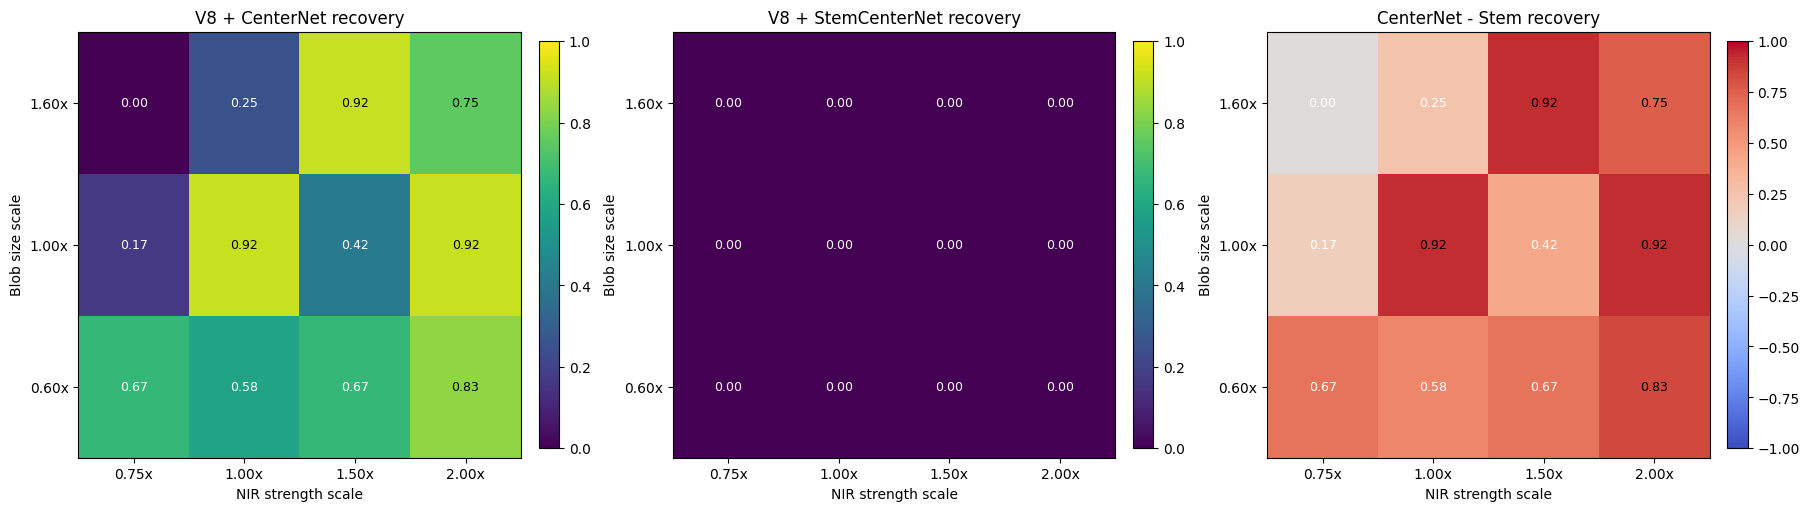

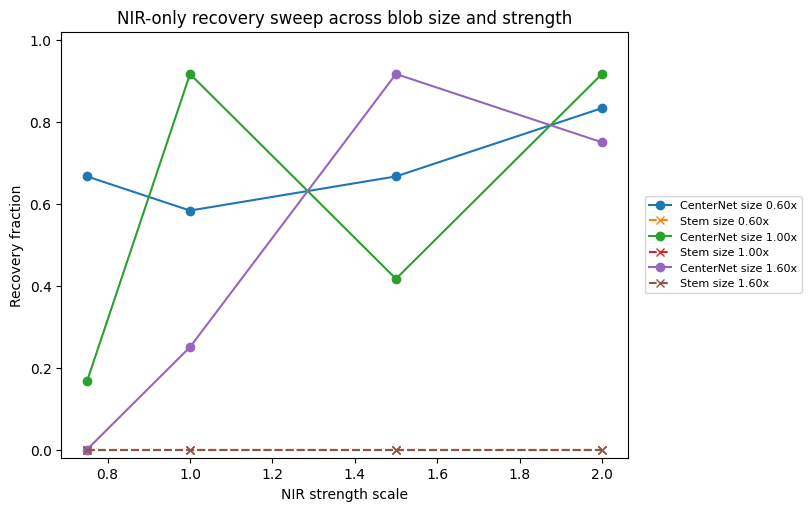

In [14]:
SWEEP_RANDOM_SEED = 11
SWEEP_N_TILES = 4
SWEEP_TRIALS_PER_TILE = 3
SWEEP_SIZE_SCALES = [0.6, 1.0, 1.6]
SWEEP_STRENGTH_SCALES = [0.75, 1.0, 1.5, 2.0]


def list_shared_tile_names(rubin_dir: Path, euclid_dir: Path) -> list[str]:
    rubin_stems = sorted(p.stem for p in rubin_dir.glob('tile_x*_y*.npz'))
    return [stem for stem in rubin_stems if (euclid_dir / f'{stem}_euclid.npz').exists()]


def scaled_snr_dict(base: dict, scale: float) -> dict:
    return {band: float(val * scale) for band, val in base.items()}


shared_tiles = list_shared_tile_names(RUBIN_DIR, EUCLID_DIR)
rng = np.random.default_rng(SWEEP_RANDOM_SEED)
chosen_tiles = list(rng.choice(shared_tiles, size=min(SWEEP_N_TILES, len(shared_tiles)), replace=False))

centernet_frac = np.zeros((len(SWEEP_SIZE_SCALES), len(SWEEP_STRENGTH_SCALES)), dtype=np.float32)
stem_frac = np.zeros_like(centernet_frac)
total_trials_grid = np.zeros_like(centernet_frac)

for i_size, size_scale in enumerate(SWEEP_SIZE_SCALES):
    for j_strength, strength_scale in enumerate(SWEEP_STRENGTH_SCALES):
        c_hits = 0
        s_hits = 0
        total = 0
        snr_dict = scaled_snr_dict(INJECT_SNR_BY_BAND, strength_scale)
        sigma_x = INJECT_SIGMA_X_PX * size_scale
        sigma_y = INJECT_SIGMA_Y_PX * size_scale

        for tile_idx, tile_name in enumerate(chosen_tiles):
            sweep_tile = load_tile_pair(tile_name, RUBIN_DIR, EUCLID_DIR, DEVICE)
            sweep_vis_norm, _, _, _ = _pseudo_labels_vis(sweep_tile['vis_img'], nsig=CLASSICAL_VIS_NSIG, max_sources=1000)
            sweep_vis_xy = vis_centroids_to_xy(sweep_vis_norm, sweep_tile['vis_hw'])
            sweep_c_xy, _ = run_detector(centernet, sweep_tile['images'], sweep_tile['rms'], sweep_tile['vis_hw'], CENTERNET_CONF_THRESHOLD)
            sweep_s_xy, _ = run_detector(stem_centernet, sweep_tile['images'], sweep_tile['rms'], sweep_tile['vis_hw'], STEM_CENTERNET_CONF_THRESHOLD)
            existing_xy = np.concatenate([arr for arr in [sweep_vis_xy, sweep_c_xy, sweep_s_xy] if len(arr)], axis=0) if any(len(arr) for arr in [sweep_vis_xy, sweep_c_xy, sweep_s_xy]) else np.zeros((0, 2), dtype=np.float32)

            inject_xy_local = pick_injection_positions(
                existing_xy=existing_xy,
                hw=sweep_tile['vis_hw'],
                n_trials=SWEEP_TRIALS_PER_TILE,
                seed=SWEEP_RANDOM_SEED + 1000 * i_size + 100 * j_strength + tile_idx,
                border=INJECT_BORDER_PX,
                min_dist_px=INJECT_MIN_DIST_EXISTING_PX,
            )

            for x, y in inject_xy_local:
                injected_images = inject_gaussian_blob(
                    sweep_tile['images'],
                    sweep_tile['rms'],
                    x=float(x),
                    y=float(y),
                    sigma_x_px=sigma_x,
                    sigma_y_px=sigma_y,
                    theta_deg=INJECT_THETA_DEG,
                    snr_by_band=snr_dict,
                )
                c_xy, _ = run_detector(centernet, injected_images, sweep_tile['rms'], sweep_tile['vis_hw'], CENTERNET_CONF_THRESHOLD)
                s_xy, _ = run_detector(stem_centernet, injected_images, sweep_tile['rms'], sweep_tile['vis_hw'], STEM_CENTERNET_CONF_THRESHOLD)
                c_hit, _ = recovered_near(c_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
                s_hit, _ = recovered_near(s_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
                c_hits += int(c_hit)
                s_hits += int(s_hit)
                total += 1

        total_trials_grid[i_size, j_strength] = total
        if total > 0:
            centernet_frac[i_size, j_strength] = c_hits / total
            stem_frac[i_size, j_strength] = s_hits / total

print('Sweep tiles:')
for name in chosen_tiles:
    print(f'  - {name}')
print('Recovery fractions are over tiles x injected positions for each grid point.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plots = [
    (centernet_frac, 'V8 + CenterNet recovery', 'viridis', 0.0, 1.0),
    (stem_frac, 'V8 + StemCenterNet recovery', 'viridis', 0.0, 1.0),
    (centernet_frac - stem_frac, 'CenterNet - Stem recovery', 'coolwarm', -1.0, 1.0),
]
for ax, (arr, title, cmap, vmin, vmax) in zip(axes, plots):
    im = ax.imshow(arr, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(len(SWEEP_STRENGTH_SCALES)))
    ax.set_xticklabels([f'{s:.2f}x' for s in SWEEP_STRENGTH_SCALES])
    ax.set_yticks(range(len(SWEEP_SIZE_SCALES)))
    ax.set_yticklabels([f'{s:.2f}x' for s in SWEEP_SIZE_SCALES])
    ax.set_xlabel('NIR strength scale')
    ax.set_ylabel('Blob size scale')
    for ii in range(arr.shape[0]):
        for jj in range(arr.shape[1]):
            ax.text(jj, ii, f'{arr[ii, jj]:.2f}', ha='center', va='center', color='white' if abs(arr[ii, jj]) < 0.7 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for i_size, size_scale in enumerate(SWEEP_SIZE_SCALES):
    ax.plot(SWEEP_STRENGTH_SCALES, centernet_frac[i_size], marker='o', label=f'CenterNet size {size_scale:.2f}x')
    ax.plot(SWEEP_STRENGTH_SCALES, stem_frac[i_size], marker='x', linestyle='--', label=f'Stem size {size_scale:.2f}x')
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('NIR strength scale')
ax.set_ylabel('Recovery fraction')
ax.set_title('NIR-only recovery sweep across blob size and strength')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()
